# 03 - Musicas brasileiras: filtro e estatisticas

Este notebook identifica faixas brasileiras no dataset Spotify Metadata a partir dos generos associados aos artistas e calcula estatisticas descritivas sobre essas faixas.

Objetivos:
- criar um filtro explicito e ajustavel para musicas brasileiras;
- medir volume de faixas, artistas, albuns, anos e generos;
- analisar popularidade, duracao, conteudo explicito e atributos de audio;
- comparar o subconjunto brasileiro com o restante do dataset.

## 0. Imports e configuracao

In [1]:
from __future__ import annotations

from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 5)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


## 1. Caminhos e criterio do filtro

O dataset nao possui uma coluna de nacionalidade do artista. Por isso, o filtro abaixo usa os generos do Spotify ligados aos artistas. O DuckDB aplica `strip_accents()` antes do regex, entao generos como `forro`/`forro` acentuado, `axe`/`axe` acentuado e `baiao`/`baiao` acentuado entram no mesmo criterio.

A lista `BR_TERMS` pode ser refinada para aumentar precisao ou cobertura.

In [2]:
DATASET_DIR = Path("../data/spotify-metadata")
CLEAN_DIR = DATASET_DIR / "spotify_clean_parquet"
AUDIO_DIR = DATASET_DIR / "spotify_clean_audio_features_parquet"

required_files = [
    CLEAN_DIR / "tracks.parquet",
    CLEAN_DIR / "track_artists.parquet",
    CLEAN_DIR / "artists.parquet",
    CLEAN_DIR / "artist_genres.parquet",
    CLEAN_DIR / "albums.parquet",
    AUDIO_DIR / "track_audio_features.parquet",
]

missing = [path for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Arquivos ausentes em data/spotify-metadata. "
        "Rode `./scripts/download_spotify_metadata.sh --truncated` ou `--full`.\n"
        + "\n".join(str(path) for path in missing)
    )


def sql_path(path: Path) -> str:
    return path.as_posix().replace("'", "''")


BR_TERMS = [
    "brazilian",
    "brazil",
    "brasil",
    "mpb",
    "samba",
    "sertanejo",
    "pagode",
    "forro",
    "bossa",
    "axe",
    "baiao",
    "funk carioca",
    "arrocha",
    "piseiro",
    "frevo",
    "maracatu",
    "tropicalia",
    "choro",
    "musica brasileira",
]

BR_REGEX = r"(^|[^a-z])(" + "|".join(BR_TERMS) + r")([^a-z]|$)"

con = duckdb.connect()
print(f"Dataset: {DATASET_DIR}")
print(f"Termos do filtro: {len(BR_TERMS)}")
print(BR_REGEX)

Dataset: ..\data\spotify-metadata
Termos do filtro: 19
(^|[^a-z])(brazilian|brazil|brasil|mpb|samba|sertanejo|pagode|forro|bossa|axe|baiao|funk carioca|arrocha|piseiro|frevo|maracatu|tropicalia|choro|musica brasileira)([^a-z]|$)


## 2. Tabelas temporarias DuckDB do subconjunto brasileiro

As tabelas temporarias abaixo materializam o filtro dentro do DuckDB, mas nao carregam tudo em pandas. Isso evita recalcular o regex de generos em cada estatistica.

In [3]:
tracks_path = sql_path(CLEAN_DIR / "tracks.parquet")
track_artists_path = sql_path(CLEAN_DIR / "track_artists.parquet")
artists_path = sql_path(CLEAN_DIR / "artists.parquet")
artist_genres_path = sql_path(CLEAN_DIR / "artist_genres.parquet")
albums_path = sql_path(CLEAN_DIR / "albums.parquet")
audio_path = sql_path(AUDIO_DIR / "track_audio_features.parquet")

con.execute(
    f"""
    CREATE OR REPLACE TEMP TABLE br_track_ids AS
    SELECT DISTINCT ta.track_rowid
    FROM read_parquet('{track_artists_path}') ta
    JOIN read_parquet('{artist_genres_path}') ag
      ON ag.artist_rowid = ta.artist_rowid
    WHERE regexp_matches(lower(strip_accents(coalesce(ag.genre, ''))), '{BR_REGEX}')
    """
)

con.execute(
    f"""
    CREATE OR REPLACE TEMP TABLE br_track_artists AS
    SELECT DISTINCT
        ta.track_rowid,
        ar.rowid AS artist_rowid,
        ar.id AS artist_id,
        coalesce(ar.name, '') AS artist_name,
        ar.popularity AS artist_popularity,
        ar.followers_total AS artist_followers
    FROM br_track_ids b
    JOIN read_parquet('{track_artists_path}') ta
      ON ta.track_rowid = b.track_rowid
    LEFT JOIN read_parquet('{artists_path}') ar
      ON ar.rowid = ta.artist_rowid
    """
)

con.execute(
    f"""
    CREATE OR REPLACE TEMP TABLE br_artist_genres AS
    SELECT DISTINCT
        ta.track_rowid,
        ag.artist_rowid,
        coalesce(ag.genre, '') AS genre
    FROM br_track_ids b
    JOIN read_parquet('{track_artists_path}') ta
      ON ta.track_rowid = b.track_rowid
    LEFT JOIN read_parquet('{artist_genres_path}') ag
      ON ag.artist_rowid = ta.artist_rowid
    WHERE coalesce(ag.genre, '') <> ''
    """
)

con.execute(
    f"""
    CREATE OR REPLACE TEMP TABLE br_tracks AS
    WITH artist_profile AS (
        SELECT
            track_rowid,
            string_agg(DISTINCT artist_name, ' | ' ORDER BY artist_name) AS artist_names
        FROM br_track_artists
        GROUP BY track_rowid
    ),
    genre_profile AS (
        SELECT
            track_rowid,
            string_agg(DISTINCT genre, ' | ' ORDER BY genre) AS artist_genres
        FROM br_artist_genres
        GROUP BY track_rowid
    )
    SELECT
        t.rowid AS track_rowid,
        t.id AS track_id,
        coalesce(t.name, '') AS track_name,
        t.popularity AS track_popularity,
        t.duration_ms AS duration_ms,
        t.duration_ms / 60000.0 AS duration_min,
        cast(t.explicit AS BOOLEAN) AS explicit,
        alb.id AS album_id,
        coalesce(alb.name, '') AS album_name,
        coalesce(alb.album_type, '') AS album_type,
        coalesce(alb.label, '') AS label,
        alb.popularity AS album_popularity,
        coalesce(alb.release_date, '') AS release_date,
        try_cast(regexp_extract(coalesce(alb.release_date, ''), '^[0-9]{{4}}') AS INTEGER) AS release_year,
        coalesce(ap.artist_names, '') AS artist_names,
        coalesce(gp.artist_genres, '') AS artist_genres,
        try_cast(nullif(af.acousticness, '') AS DOUBLE) AS acousticness,
        try_cast(nullif(af.danceability, '') AS DOUBLE) AS danceability,
        try_cast(nullif(af.energy, '') AS DOUBLE) AS energy,
        try_cast(nullif(af.valence, '') AS DOUBLE) AS valence,
        try_cast(nullif(af.speechiness, '') AS DOUBLE) AS speechiness,
        try_cast(nullif(af.instrumentalness, '') AS DOUBLE) AS instrumentalness,
        try_cast(nullif(af.liveness, '') AS DOUBLE) AS liveness,
        try_cast(nullif(af.tempo, '') AS DOUBLE) AS tempo,
        try_cast(nullif(af.loudness, '') AS DOUBLE) AS loudness,
        try_cast(nullif(af.key, '') AS INTEGER) AS key,
        try_cast(nullif(af.mode, '') AS INTEGER) AS mode,
        try_cast(nullif(af.time_signature, '') AS INTEGER) AS time_signature
    FROM br_track_ids b
    JOIN read_parquet('{tracks_path}') t
      ON t.rowid = b.track_rowid
    LEFT JOIN read_parquet('{albums_path}') alb
      ON alb.rowid = t.album_rowid
    LEFT JOIN artist_profile ap
      ON ap.track_rowid = t.rowid
    LEFT JOIN genre_profile gp
      ON gp.track_rowid = t.rowid
    LEFT JOIN read_parquet('{audio_path}') af
      ON af.track_id = t.id
    """
)

print("Tabelas temporarias criadas: br_track_ids, br_track_artists, br_artist_genres, br_tracks")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Tabelas temporarias criadas: br_track_ids, br_track_artists, br_artist_genres, br_tracks


## 3. Visao geral do subconjunto

In [4]:
overview_df = con.execute(
    """
    WITH track_stats AS (
        SELECT
            count(*) AS faixas,
            count(DISTINCT album_id) AS albuns,
            count(DISTINCT nullif(label, '')) AS labels,
            count(*) FILTER (WHERE danceability IS NOT NULL) AS faixas_com_audio,
            100 * avg(CASE WHEN explicit THEN 1 ELSE 0 END) AS faixas_explicit_pct,
            min(release_year) FILTER (WHERE release_year BETWEEN 1900 AND 2100) AS ano_min,
            max(release_year) FILTER (WHERE release_year BETWEEN 1900 AND 2100) AS ano_max
        FROM br_tracks
    ),
    artist_stats AS (
        SELECT count(DISTINCT artist_rowid) AS artistas
        FROM br_track_artists
    )
    SELECT 'faixas' AS metrica, faixas::DOUBLE AS valor FROM track_stats
    UNION ALL SELECT 'artistas', artistas::DOUBLE FROM artist_stats
    UNION ALL SELECT 'albuns', albuns::DOUBLE FROM track_stats
    UNION ALL SELECT 'labels', labels::DOUBLE FROM track_stats
    UNION ALL SELECT 'faixas_com_audio', faixas_com_audio::DOUBLE FROM track_stats
    UNION ALL SELECT 'faixas_explicit_%', faixas_explicit_pct FROM track_stats
    UNION ALL SELECT 'ano_min', ano_min::DOUBLE FROM track_stats
    UNION ALL SELECT 'ano_max', ano_max::DOUBLE FROM track_stats
    """
).fetchdf()

overview_df

,metrica,valor
0,faixas,3.418482e+06
1,artistas,2.759990e+05
2,albuns,9.730490e+05
3,labels,1.253130e+05
4,faixas_com_audio,3.413444e+06
5,faixas_explicit_%,1.420484e+01
6,ano_min,1.900000e+03
7,ano_max,2.026000e+03


In [5]:
con.execute(
    """
    SELECT
        track_id,
        track_name,
        artist_names,
        album_name,
        release_date,
        track_popularity,
        duration_min,
        explicit,
        artist_genres
    FROM br_tracks
    ORDER BY track_popularity DESC NULLS LAST, track_name
    LIMIT 20
    """
).fetchdf()

,track_id,track_name,artist_names,album_name,release_date,track_popularity,duration_min,explicit,artist_genres
0,7DY756WOLyOz2Xnhw4EFiC,São Paulo (feat. Anitta),Anitta | The Weeknd,Hurry Up Tomorrow,2025-01-31,87,5.027050,True,brazilian pop | funk | funk carioca | funk pop | pagode baiano
1,4Hk1gmBr2KVEXr3hHwSgUi,Mãe Solteira,DG e Batidão Stronda | J. Eskine | MC G15 | Mc Davi,Mãe Solteira,2025-03-03,85,2.400000,False,arrocha | brazilian funk | forró | funk | funk consciente | piseiro | seresta | trap funk
2,0BUkQGUXgcvf3gdCWYbtnJ,Oh Garota Eu Quero Você Só Pra Mim,Dj Lc da Roça | MC K9 | MC Tuto | Mc Rodrigo do CN | Oruam | Zé Felipe | mc pl alves,Oh Garota Eu Quero Você Só Pra Mim,2024-12-17,85,2.781017,True,agronejo | arrocha | brazilian funk | brazilian trap | forró | funk | funk carioca | funk consciente | funk de bh | ...
3,0NQyryTVbjGMtWMA1eSqIn,Resenha do Arrocha,Alef Donk | J. Eskine,Resenha do Arrocha,2024-11-29,85,5.914283,True,arrocha | forró | piseiro | seresta
4,4pOGEJRVOuaa9oyy7qTGf6,Fui Mlk,DJ Di Marques | FamousKyo | Mc Paiva ZS | Nilo,Fui Mlk,2024-11-22,84,2.901833,False,brazilian funk | brazilian trap | funk | funk carioca | funk consciente | trap funk
5,6Emsu0BaMpG0ilZCRT8KHZ,Tubarões - Ao Vivo,Diego & Victor Hugo,Tubarões (Ao Vivo),2025-02-13,84,2.709667,False,agronejo | arrocha | piseiro | sertanejo | sertanejo universitário
6,5496lks6V3fh1mZAB6IAap,Alibi (with Pabllo Vittar & Yseult),Pabllo Vittar | Sevdaliza | Yseult,Alibi (with Pabllo Vittar & Yseult),2024-06-28,83,2.694250,False,brazilian pop | funk pop | tecnobrega
7,2OMkXPz6pHdKJSkzxG0MwZ,Descer,Dj LK da Escócia | Kew,Descer,2025-01-30,83,1.860883,True,brazilian funk | funk | funk carioca
8,7IBqHkoP94VrgYKVns4eNz,FUNK DO BOUNCE (Slowed),Ariis,FUNK DO BOUNCE (Slowed),2024-08-30,83,1.792317,False,brazilian phonk | phonk
9,43jExF2HeZ6cJIGrWF0ie4,Funk de Beleza - Slowed,Nateki | Scythermane,Funk de Beleza,2024-10-04,83,2.418583,True,brazilian phonk | drift phonk | phonk


## 4. Estatisticas numericas

In [6]:
NUMERIC_COLS = [
    "track_popularity",
    "album_popularity",
    "duration_min",
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness",
    "tempo",
    "loudness",
]


def numeric_profile(table: str, columns: list[str]) -> pd.DataFrame:
    parts = []
    for col in columns:
        parts.append(
            f"""
            SELECT
                '{col}' AS coluna,
                count({col}) AS n,
                avg({col}) AS media,
                stddev_samp({col}) AS desvio,
                min({col}) AS min,
                quantile_cont({col}, 0.25) AS q25,
                median({col}) AS mediana,
                quantile_cont({col}, 0.75) AS q75,
                max({col}) AS max
            FROM {table}
            WHERE {col} IS NOT NULL
            """
        )
    query = "\nUNION ALL\n".join(parts)
    return con.execute(query).fetchdf().round(3)


stats_numeric = numeric_profile("br_tracks", NUMERIC_COLS)
stats_numeric

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,coluna,n,media,desvio,min,q25,mediana,q75,max
0,track_popularity,3418482,3.782,8.653,0.0,0.000,0.000,2.000,87.000
1,album_popularity,3418482,5.611,10.699,0.0,0.000,0.000,6.000,92.000
2,duration_min,3418482,3.303,1.540,0.0,2.451,3.084,3.837,180.000
3,danceability,3413444,0.640,0.162,0.0,0.538,0.657,0.755,0.999
4,energy,3413444,0.594,0.248,0.0,0.415,0.630,0.800,1.000
5,valence,3413444,0.596,0.260,0.0,0.393,0.631,0.819,1.000
6,acousticness,3413444,0.451,0.314,0.0,0.160,0.439,0.726,0.996
7,speechiness,3413444,0.095,0.110,0.0,0.037,0.050,0.094,0.971
8,instrumentalness,3413444,0.176,0.329,0.0,0.000,0.000,0.090,1.000
9,liveness,3413444,0.219,0.196,0.0,0.099,0.133,0.279,1.000


## 5. Artistas, generos e albuns

,artist_name,faixas,popularidade_media,seguidores
0,Mc Gw,30057,78.063280,1567394
1,LOVE BOSSA,29281,45.986169,4114
2,Massage Music,24536,40.000000,15270
3,Jazzical Blue,19602,24.000000,921
4,João Gilberto,13577,63.908080,669601
5,Stan Getz,12784,66.000000,503392
6,Showlivre,11720,53.000000,5519
7,Classic Jazz,11472,21.989801,4487
8,Chill Cats,11160,1.000000,8
9,Caterina Valente,10270,43.000000,45840


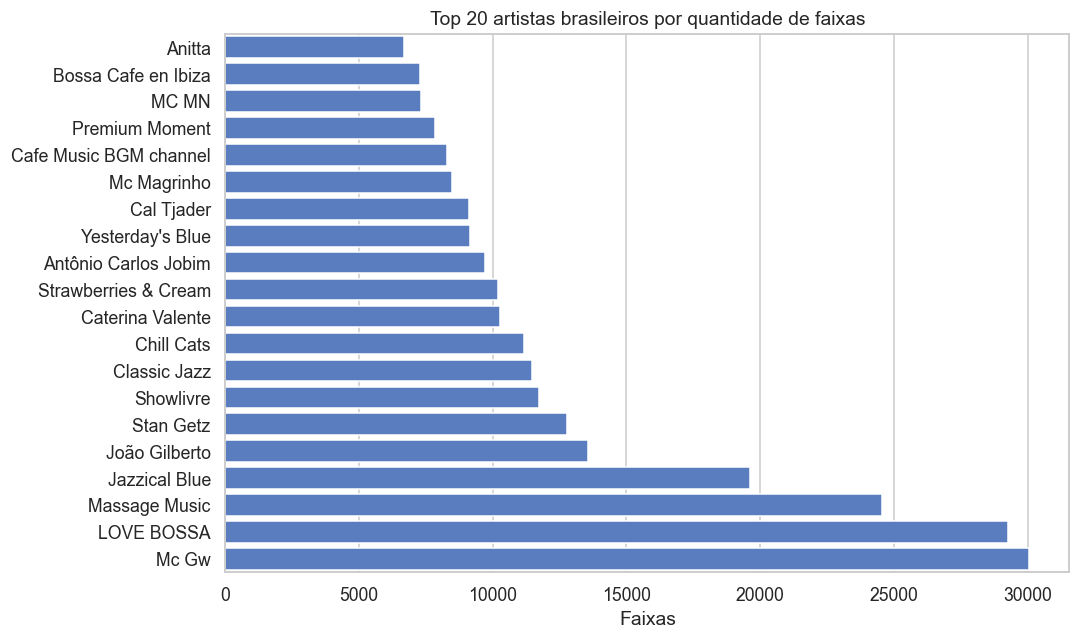

In [7]:
top_artists = con.execute(
    """
    SELECT
        artist_name,
        count(DISTINCT track_rowid) AS faixas,
        avg(artist_popularity) AS popularidade_media,
        max(artist_followers) AS seguidores
    FROM br_track_artists
    WHERE artist_name <> ''
    GROUP BY artist_name
    ORDER BY faixas DESC, popularidade_media DESC NULLS LAST
    LIMIT 20
    """
).fetchdf()

display(top_artists)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_artists.sort_values("faixas"), x="faixas", y="artist_name", ax=ax)
ax.set_title("Top 20 artistas brasileiros por quantidade de faixas")
ax.set_xlabel("Faixas")
ax.set_ylabel("")
plt.tight_layout()

,genre,faixas
0,bossa nova,659513
1,forró,563261
2,brazilian jazz,376871
3,arrocha,327714
4,piseiro,315083
5,samba,303064
6,mpb,294439
7,brazilian funk,262667
8,brazilian evangelical music,235785
9,brazilian phonk,222373


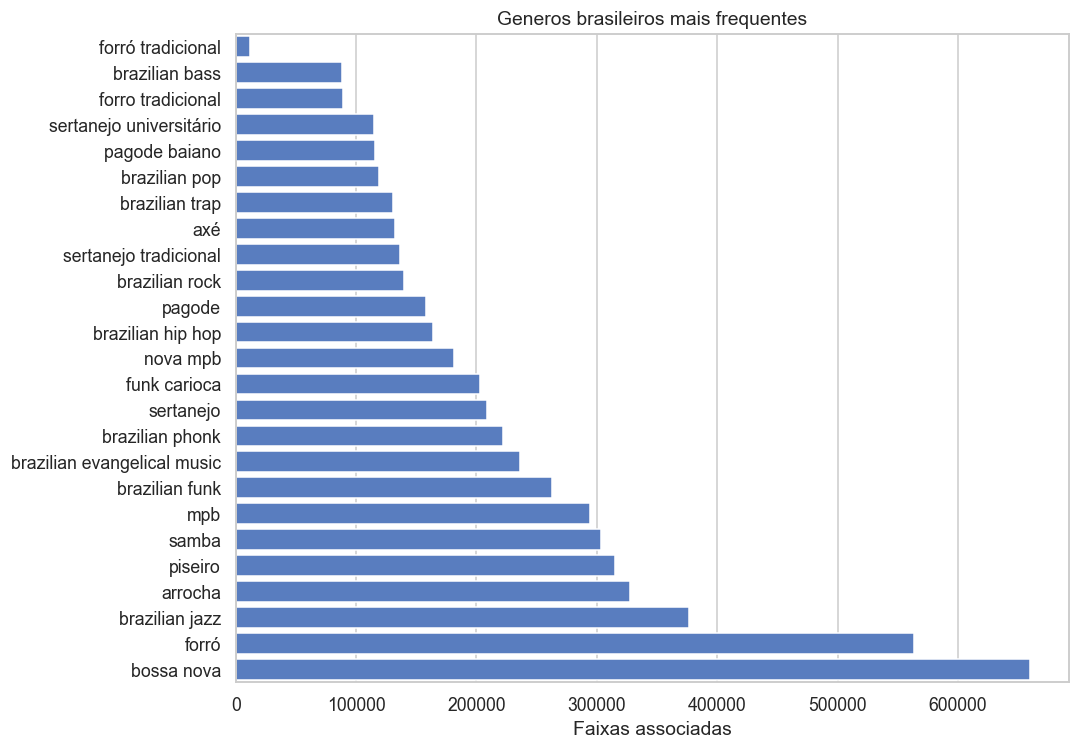

In [8]:
top_genres = con.execute(
    f"""
    SELECT
        genre,
        count(DISTINCT track_rowid) AS faixas
    FROM br_artist_genres
    WHERE regexp_matches(lower(strip_accents(genre)), '{BR_REGEX}')
    GROUP BY genre
    ORDER BY faixas DESC
    LIMIT 25
    """
).fetchdf()

display(top_genres)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top_genres.sort_values("faixas"), x="faixas", y="genre", ax=ax)
ax.set_title("Generos brasileiros mais frequentes")
ax.set_xlabel("Faixas associadas")
ax.set_ylabel("")
plt.tight_layout()

In [9]:
album_types = con.execute(
    """
    SELECT
        coalesce(nullif(album_type, ''), '(sem tipo)') AS album_type,
        count(*) AS faixas,
        count(DISTINCT album_id) AS albuns,
        avg(track_popularity) AS popularidade_media
    FROM br_tracks
    GROUP BY album_type
    ORDER BY faixas DESC
    """
).fetchdf()

album_types

,album_type,faixas,albuns,popularidade_media
0,album,2081666,174349,3.554889
1,single,956413,726433,5.180839
2,compilation,380403,72267,1.507007


## 6. Distribuicao temporal

,release_year,faixas,popularidade_media
81,2007,33843,4.326685
82,2008,37716,3.541256
83,2009,42799,3.380873
84,2010,46365,3.132708
85,2011,51707,2.787592
86,2012,65057,3.081221
87,2013,86999,2.439327
88,2014,98042,2.719222
89,2015,95929,3.072168
90,2016,92863,3.158739


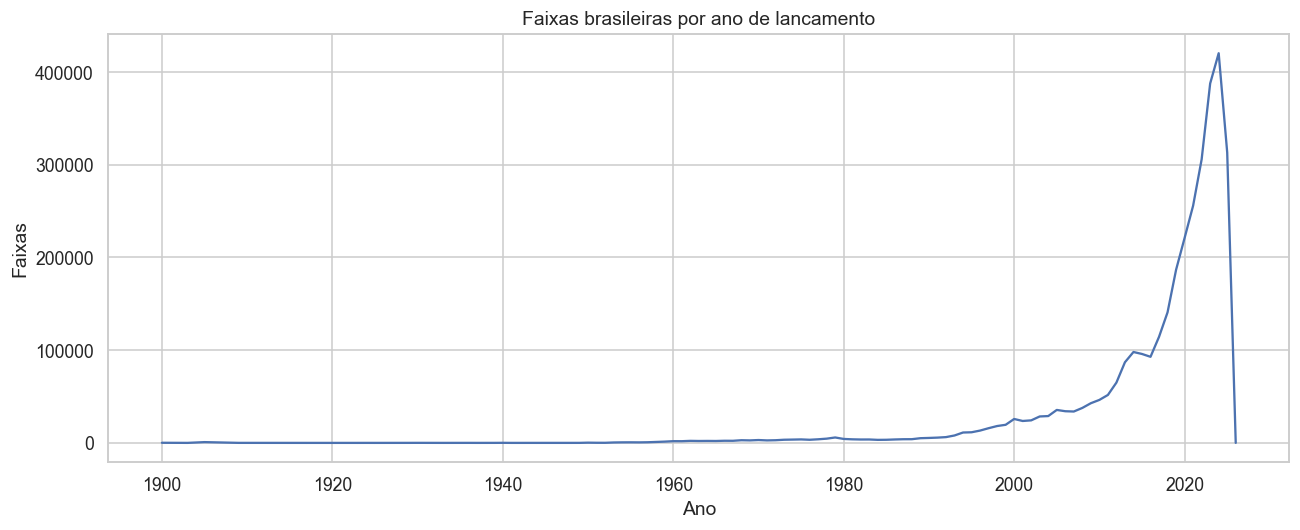

In [10]:
tracks_by_year = con.execute(
    """
    SELECT
        release_year,
        count(*) AS faixas,
        avg(track_popularity) AS popularidade_media
    FROM br_tracks
    WHERE release_year BETWEEN 1900 AND 2100
    GROUP BY release_year
    ORDER BY release_year
    """
).fetchdf()

display(tracks_by_year.tail(20))

fig, ax1 = plt.subplots(figsize=(12, 5))
sns.lineplot(data=tracks_by_year, x="release_year", y="faixas", ax=ax1, color="#4c72b0")
ax1.set_title("Faixas brasileiras por ano de lancamento")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Faixas")
plt.tight_layout()

## 7. Atributos de audio

,atributo,media
0,danceability,0.640
1,energy,0.594
2,valence,0.596
3,acousticness,0.451
4,speechiness,0.095
5,instrumentalness,0.176
6,liveness,0.219


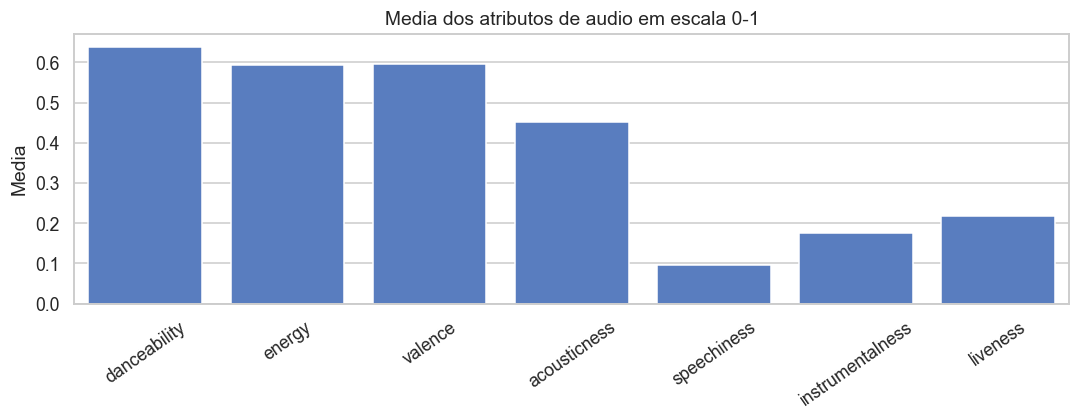

In [11]:
AUDIO_01_COLS = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness",
]

audio_means = con.execute(
    """
    SELECT
        avg(danceability) AS danceability,
        avg(energy) AS energy,
        avg(valence) AS valence,
        avg(acousticness) AS acousticness,
        avg(speechiness) AS speechiness,
        avg(instrumentalness) AS instrumentalness,
        avg(liveness) AS liveness
    FROM br_tracks
    """
).fetchdf().T.reset_index()
audio_means.columns = ["atributo", "media"]

display(audio_means.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=audio_means, x="atributo", y="media", ax=ax)
ax.set_title("Media dos atributos de audio em escala 0-1")
ax.set_xlabel("")
ax.set_ylabel("Media")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()

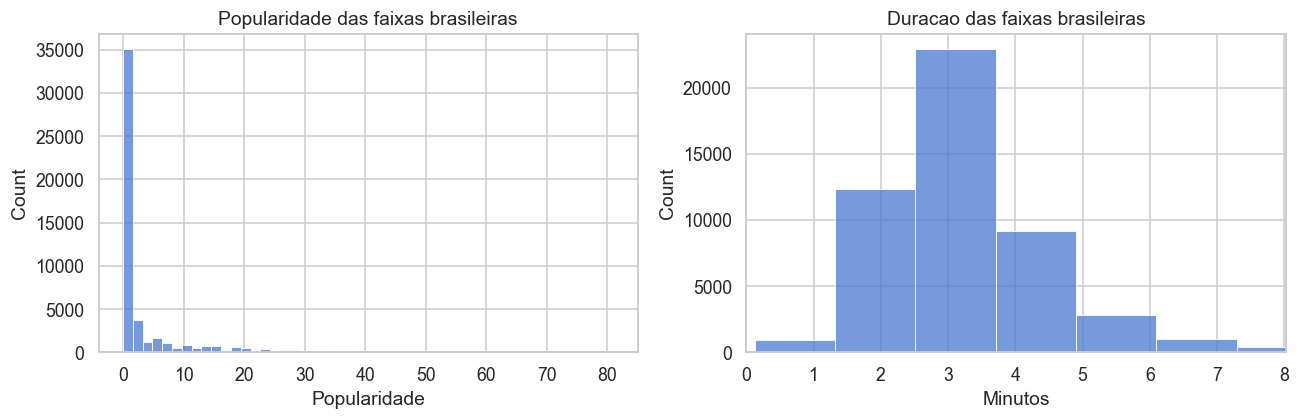

In [12]:
SAMPLE_ROWS = 50_000

audio_sample = con.execute(
    f"""
    SELECT
        track_popularity,
        duration_min,
        danceability,
        energy,
        valence,
        acousticness,
        speechiness,
        instrumentalness,
        liveness,
        tempo,
        loudness
    FROM br_tracks
    WHERE danceability IS NOT NULL
    LIMIT {SAMPLE_ROWS}
    """
).fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(audio_sample["track_popularity"].dropna(), bins=50, ax=axes[0])
axes[0].set_title("Popularidade das faixas brasileiras")
axes[0].set_xlabel("Popularidade")

sns.histplot(audio_sample["duration_min"].dropna(), bins=50, ax=axes[1])
axes[1].set_title("Duracao das faixas brasileiras")
axes[1].set_xlabel("Minutos")
axes[1].set_xlim(0, audio_sample["duration_min"].quantile(0.99))

plt.tight_layout()

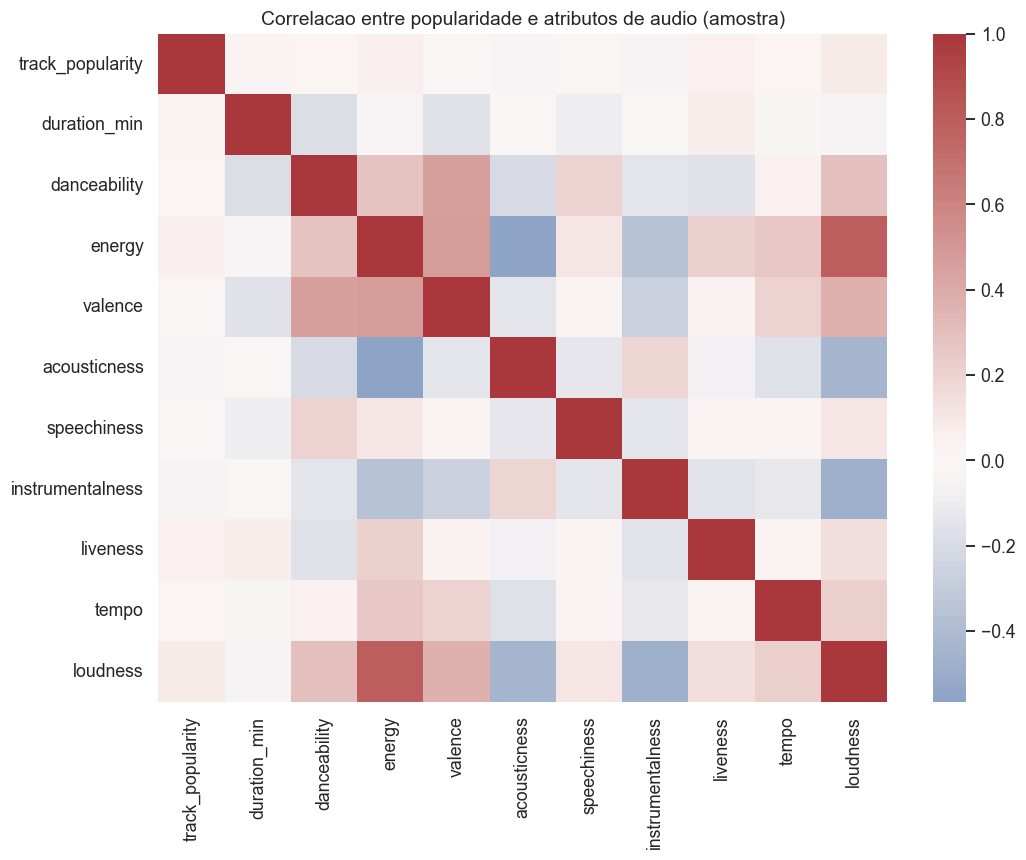

In [13]:
corr_cols = [
    "track_popularity",
    "duration_min",
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness",
    "tempo",
    "loudness",
]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(audio_sample[corr_cols].corr(), cmap="vlag", center=0, annot=False, ax=ax)
ax.set_title("Correlacao entre popularidade e atributos de audio (amostra)")
plt.tight_layout()

## 8. Comparacao: brasileiro vs. restante do dataset

In [14]:
comparison = con.execute(
    f"""
    SELECT
        CASE WHEN b.track_rowid IS NULL THEN 'Nao brasileiro' ELSE 'Brasileiro' END AS grupo,
        count(*) AS faixas,
        avg(t.popularity) AS popularidade_media,
        avg(t.duration_ms / 60000.0) AS duracao_media_min,
        100 * avg(CASE WHEN cast(t.explicit AS BOOLEAN) THEN 1 ELSE 0 END) AS explicit_pct,
        avg(try_cast(nullif(af.danceability, '') AS DOUBLE)) AS danceability,
        avg(try_cast(nullif(af.energy, '') AS DOUBLE)) AS energy,
        avg(try_cast(nullif(af.valence, '') AS DOUBLE)) AS valence,
        avg(try_cast(nullif(af.acousticness, '') AS DOUBLE)) AS acousticness,
        avg(try_cast(nullif(af.tempo, '') AS DOUBLE)) AS tempo
    FROM read_parquet('{tracks_path}') t
    LEFT JOIN br_track_ids b
      ON b.track_rowid = t.rowid
    LEFT JOIN read_parquet('{audio_path}') af
      ON af.track_id = t.id
    GROUP BY grupo
    ORDER BY grupo
    """
).fetchdf().round(3)

comparison

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,grupo,faixas,popularidade_media,duracao_media_min,explicit_pct,danceability,energy,valence,acousticness,tempo
0,Brasileiro,3418482,3.782,3.303,14.205,0.640,0.594,0.596,0.451,122.913
1,Nao brasileiro,252620525,1.354,3.613,13.500,0.564,0.505,0.436,0.419,118.272


## 9. Opcional: exportar amostra filtrada

Ative `EXPORT_SAMPLE = True` para salvar uma amostra CSV em `data/derived/`. O padrao fica desligado para evitar criar arquivos grandes sem querer.

In [15]:
EXPORT_SAMPLE = False
EXPORT_ROWS = 100_000
OUTPUT_DIR = Path("../data/derived")
OUTPUT_PATH = OUTPUT_DIR / "musicas_brasileiras_amostra.csv"

if EXPORT_SAMPLE:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    sample_export = con.execute(
        f"""
        SELECT
            track_id,
            track_name,
            artist_names,
            album_name,
            release_date,
            track_popularity,
            duration_min,
            explicit,
            artist_genres
        FROM br_tracks
        ORDER BY track_popularity DESC NULLS LAST
        LIMIT {EXPORT_ROWS}
        """
    ).fetchdf()
    sample_export.to_csv(OUTPUT_PATH, index=False)
    print(f"Amostra exportada para {OUTPUT_PATH}")
else:
    print("Exportacao desativada.")

Exportacao desativada.
